In [1]:
import numpy as np
import physipy as phys
import matplotlib.pyplot as plt
import math

In [2]:
g = 1 # Na
grid = phys.Grid(r_min = 0.01, r_max = 5, h = 1e-3)
alpha = 1

In [3]:
coord = np.arange(grid.r_min, grid.r_max + grid.h, grid.h)

alpha = 0.10
No classical region detected.
Found energy at : E = 1.514 l = 0 h = 0.001
Found energy at : E = 3.518 l = 0 h = 0.001
Found energy at : E = 5.522 l = 0 h = 0.001
Found energy at : E = 7.526 l = 0 h = 0.001
Found energy at : E = 9.529 l = 0 h = 0.001
alpha = 0.20
No classical region detected.
Found energy at : E = 1.519 l = 0 h = 0.001
Found energy at : E = 3.522 l = 0 h = 0.001
Found energy at : E = 5.525 l = 0 h = 0.001
Found energy at : E = 7.528 l = 0 h = 0.001
Found energy at : E = 9.532 l = 0 h = 0.001
alpha = 0.30
No classical region detected.
Found energy at : E = 1.529 l = 0 h = 0.001
Found energy at : E = 3.528 l = 0 h = 0.001
Found energy at : E = 5.530 l = 0 h = 0.001
Found energy at : E = 7.532 l = 0 h = 0.001
Found energy at : E = 9.535 l = 0 h = 0.001
alpha = 0.40
No classical region detected.
Found energy at : E = 1.543 l = 0 h = 0.001
Found energy at : E = 3.537 l = 0 h = 0.001
Found energy at : E = 5.537 l = 0 h = 0.001
Found energy at : E = 7.538 l = 0 h 

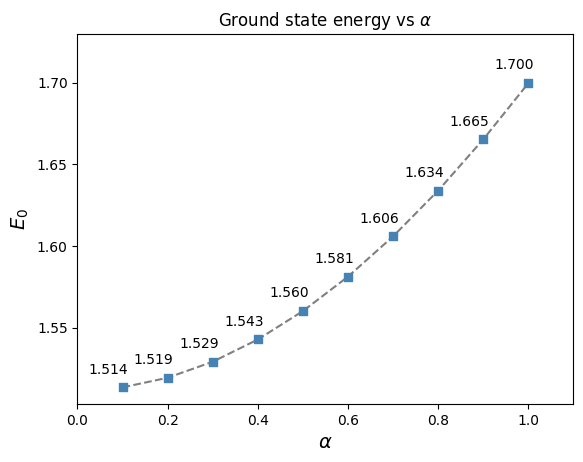

In [4]:
from scipy.integrate import simpson

E = np.arange(0, 10, 0.1)
l = np.array([0, ])
gr_energies = []

alphas  = np.arange(.1, 1.1, .1)

cmap = plt.get_cmap('tab20')
i = 0

for alpha in alphas:
    print(f'alpha = {alpha:.2f}')
    phi_guess = alpha * np.exp(-np.pow(coord, 2) / 2) * coord / math.pow(math.pi, 1/4)
    kwargs = {'g' : g, 'phi' : phi_guess, 'r_min' : grid.r_min, 'r_max' : grid.r_max, 'h' : grid.h}
    eigenstates = phys.energy_levels(E, l, phys.potentials.gross_pitaevskij, 0 , grid = grid, solver = phys.SolverOpts(), **kwargs)
    gr_energies.append(eigenstates[0].E)

for xi, yi in zip(alphas, gr_energies):
    plt.annotate(f'{yi:.3f}', (xi, yi), 
                 textcoords='offset points', 
                 xytext=(-10, 10),  # offset in points: (horizontal, vertical)
                 ha='center')
plt.plot(alphas, gr_energies, color='grey', linestyle='dashed', zorder=1)
plt.scatter(alphas, gr_energies, marker='s', color='steelblue', zorder=2)
plt.title("Ground state energy vs " + r'$\alpha$')
plt.xlim(0, 1.1)
plt.ylim(np.min(gr_energies) - 0.01, np.max(gr_energies) + 0.03)
plt.xlabel(r'$\alpha$', fontsize = 14)
plt.ylabel(r'$E_0$', fontsize = 14)
plt.show()